In [1]:
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import numpy as np
import ssl
from tqdm import tqdm
import pandas as pd
from PIL import Image

## train

In [9]:
data_dir = "images_3"
train_dir = os.path.join(data_dir, "train_images")
val_dir = os.path.join(data_dir, "val_images")
test_dir = os.path.join(data_dir, "test_images")

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, transform=transform['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=transform['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

In [10]:
ssl._create_default_https_context = ssl._create_unverified_context

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
batch_size = 32
num_epochs = 20

model = models.vgg16(models.VGG16_Weights.IMAGENET1K_V1)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

c:\Users\Administrator\Desktop\vgg16\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [13]:
num_epochs = 20
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = correct / total
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/20: 100%|██████████| 563/563 [03:50<00:00,  2.44it/s]


Epoch 1: Train Loss: 1.1360, Train Acc: 0.6523, Val Loss: 0.7092, Val Acc: 0.7992


Epoch 2/20: 100%|██████████| 563/563 [03:52<00:00,  2.42it/s]


Epoch 2: Train Loss: 0.9843, Train Acc: 0.6885, Val Loss: 0.7008, Val Acc: 0.8272


Epoch 3/20: 100%|██████████| 563/563 [03:52<00:00,  2.42it/s]


...

Epoch 18: Train Loss: 0.8172, Train Acc: 0.7508, Val Loss: 0.6054, Val Acc: 0.8901


Epoch 19/20: 100%|██████████| 563/563 [02:42<00:00,  3.46it/s]


Epoch 19: Train Loss: 0.8261, Train Acc: 0.7460, Val Loss: 0.6260, Val Acc: 0.8931


Epoch 20/20: 100%|██████████| 563/563 [02:45<00:00,  3.40it/s]


Epoch 20: Train Loss: 0.8243, Train Acc: 0.7465, Val Loss: 0.6774, Val Acc: 0.8951


In [14]:
torch.save(model.state_dict(), 'vgg16_finetuned.pth')

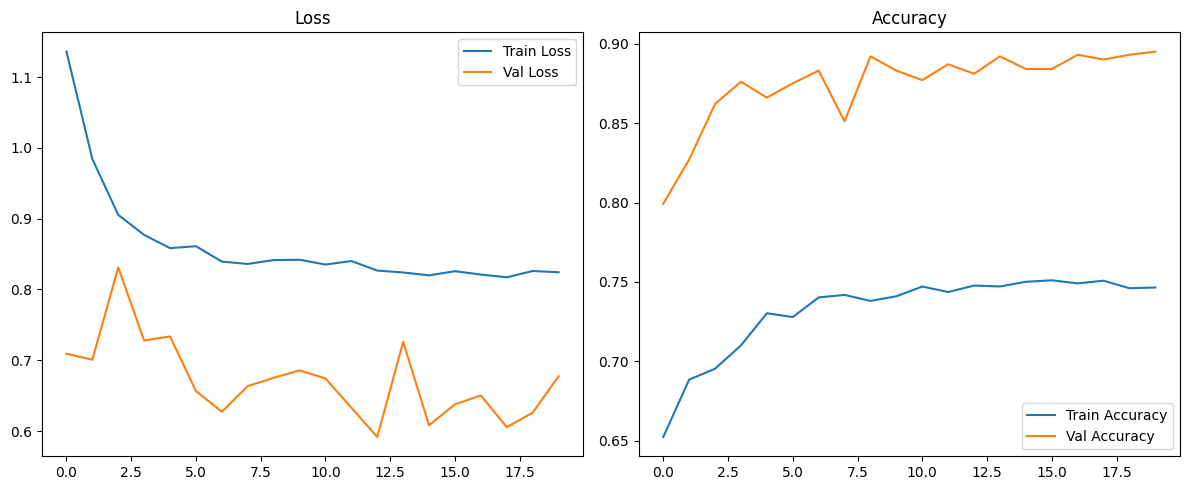

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(val_acc_history, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.tight_layout()
plt.show()

## đánh giá

In [2]:
data_dir = "data/images_3"
test_dir = os.path.join(data_dir, "test_images")

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(test_dataset.classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.vgg16(models.VGG16_Weights.IMAGENET1K_V1)
for param in model.features.parameters():
    param.requires_grad = False

model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)

model.load_state_dict(torch.load("temp/models/vgg16_finetuned.pth",  map_location=device))

label_map = {'BENIGN': 0, 'Group1' : 1, 'Group2': 2, "Syn": 3 }

f:\NCKH\code\DN\IDS-RESNET-50-System\train_model\.venv\Lib\site-packages\torchvision\models\_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [ ]:
test_accuracy = accuracy_score(y_true, y_pred)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 89.45%


              precision    recall  f1-score   support

           0       0.93      0.88      0.91       250
           1       0.91      0.89      0.90       250
           2       0.91      0.87      0.89       251
           3       0.84      0.93      0.88       244

    accuracy                           0.89       995
   macro avg       0.90      0.89      0.89       995
weighted avg       0.90      0.89      0.89       995



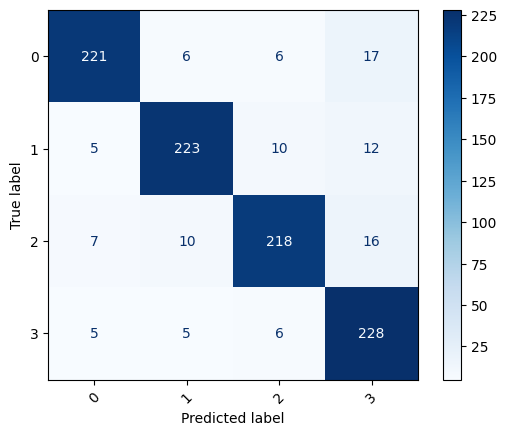

In [5]:
target_names = test_dataset.classes
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45)
plt.show()

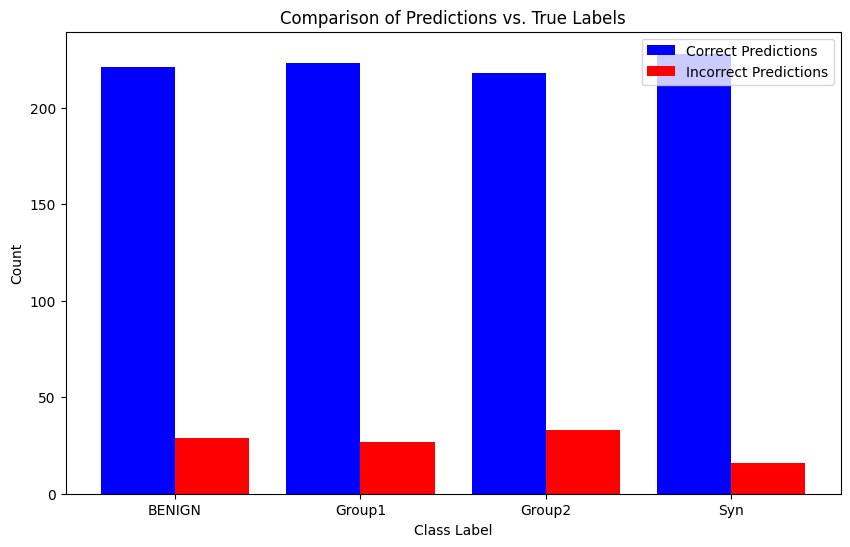

In [ ]:
df = pd.DataFrame({"True Label": y_true, "Predicted Label": y_pred})
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [ ]:
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')

def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [ ]:
labels_list = list(label_map.keys())

print(labels_list)
test_data_paths = list(map(lambda x: x, test_dataset.imgs))

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

for i in range(0, len(labels_list)):
    name_details_dict = {}

    for j in test_data_paths:
        if j[1] == i:
            r = total_predict_image(model, f"{j[0]}", labels_list)
            if r in name_details_dict:
                name_details_dict[r] += 1
            else:
                name_details_dict[r] = 1

    print(f'Label: {labels_list[i]}', name_details_dict)



['BENIGN', 'Group1', 'Group2', 'Syn']
Label: BENIGN {'BENIGN': 221, 'Group1': 6, 'Syn': 17, 'Group2': 6}
Label: Group1 {'BENIGN': 5, 'Group1': 223, 'Group2': 10, 'Syn': 12}
Label: Group2 {'BENIGN': 7, 'Group1': 10, 'Group2': 218, 'Syn': 16}
Label: Syn {'BENIGN': 5, 'Syn': 228, 'Group1': 5, 'Group2': 6}
